Classification Report
              precision    recall  f1-score   support

           0      0.975     0.804     0.882     50998
           1      0.229     0.742     0.350      4002

    accuracy                          0.800     55000
   macro avg      0.602     0.773     0.616     55000
weighted avg      0.921     0.800     0.843     55000

Confusion Matrix:
Predicted      0     1
Actual                
0          41021  9977
1           1033  2969
ROC AUC: 0.8485
Average Precision: 0.4256


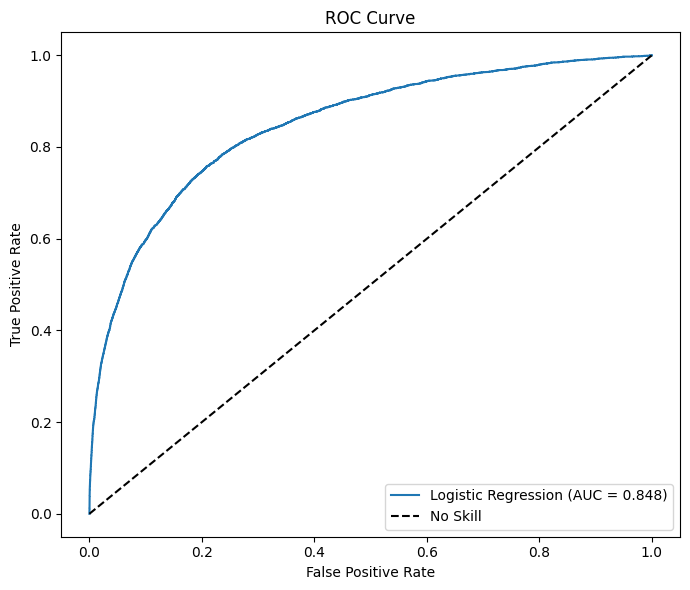

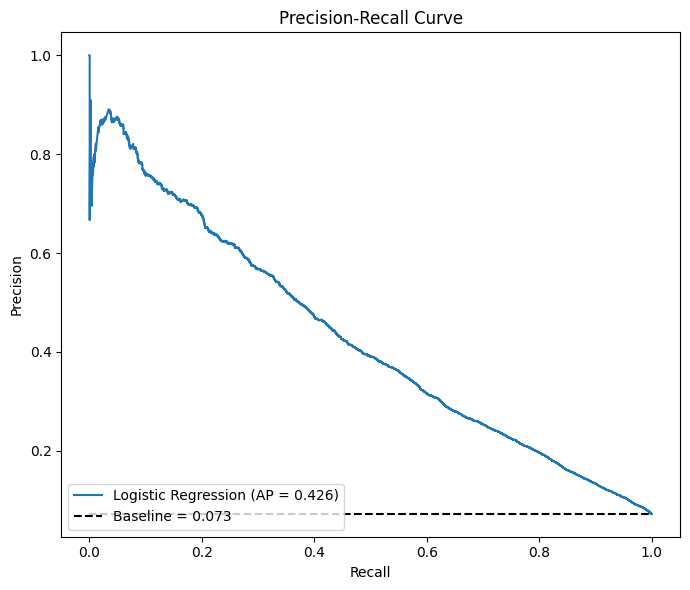

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report
)

# =========================
# 1. Load data
# =========================
csv_path = r"..\Data\SyntheticData\2026_03_30_02_10_18\synthetic_data_2026_03_30_02_10_18.csv"  # change if needed
df = pd.read_csv(csv_path)

# =========================
# 2. Build features / target
# =========================
target = "Problem_SKU"

# one-hot encode Storage_Size
size_dummies = pd.get_dummies(df["Storage_Size"], prefix="Size", drop_first=True)

# binary encode
defect_linked_num = df["Defect_In_Linked_Receive"].astype(int)

numeric_features = [
    "Global_SKU_Defect_Rate_%_std",
    "ABS_Volume_Difference_std",
    "Aisle_Hold_%_std",
    "#_Pick_Events_std",
    "#_Pick_Events_In_Clique_std",
    "#_Picks_std",
    "#_Picks_In_Clique_std",
    "Time_In_Loc_std",
    "Current_Max_Volume_std",
]

X = pd.concat([df[numeric_features], size_dummies, defect_linked_num], axis=1)
y = df[target].astype(int)

# =========================
# 3. Train/test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 4. Fit logistic regression
# =========================
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

# =========================
# 5. Predict probabilities
# =========================
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred, digits=3))
print(f"Confusion Matrix:\n{pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_proba):.4f}")

# =========================
# 6. ROC curve
# =========================
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="No Skill")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# =========================
# 7. Precision-Recall curve
# =========================
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"Logistic Regression (AP = {ap:.3f})")
baseline = y_test.mean()
plt.plot([0, 1], [baseline, baseline], "k--", label=f"Baseline = {baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


In [7]:
def threshold_for_targets(y_true, y_score, target_precision=None, target_recall=None):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    precision = precision[:-1]
    recall = recall[:-1]

    score = np.zeros_like(thresholds, dtype=float)

    if target_precision is not None:
        score += (precision - target_precision) ** 2
    if target_recall is not None:
        score += (recall - target_recall) ** 2

    best_idx = np.argmin(score)
    return thresholds[best_idx], precision[best_idx], recall[best_idx]

threshold, prec_at_threshold, rec_at_threshold = threshold_for_targets(y_test, y_proba, target_precision=.85, target_recall=.1)
print(f"Threshold for 100% precision: {threshold:.4f}")
print(f"Precision at threshold: {prec_at_threshold:.3f}")
print(f"Recall at threshold: {rec_at_threshold:.3f}")

Threshold for 100% precision: 0.9801
Precision at threshold: 0.836
Recall at threshold: 0.069
